# 02 · Quaternions

The simulator stores the aircraft's attitude as a unit quaternion and moves it forward 1000 times a second. This notebook explains what the four numbers mean, how they multiply, how they are propagated, and why Euler angles are avoided for this job.

In [1]:
# Setup: make the repository importable and load the V3 airframe used throughout these notebooks
import sys, math, pathlib
ROOT = pathlib.Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from airframe_designer.geometry.airframe import Airframe

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.grid": True, "grid.alpha": 0.3})

AF_PATH = ROOT / "airframes" / "atlas_v3_v34_foils_50_65_50_tuned.json"
af = Airframe.load(AF_PATH)
af.resolve_mass()
G = 9.80665
print(f"{af.name}: {af.mass.mass:.2f} kg, {len(af.active_rotors())} fans, hover pitch {af.hover_pitch_deg} deg, parked {af.landed_pitch_deg} deg")

ATLAS_V3_V34_FOILS_50_65_50_TUNED: 11.83 kg, 9 fans, hover pitch 23.85 deg, parked 23.85 deg


In [2]:
from airframe_designer.dynamics.quaternion import q_from_euler, q_to_rotmat, q_to_euler, q_deriv, q_normalize

## 1. Body-to-NED unit quaternion

**Theory.** A rotation by angle $\vartheta$ about the unit axis $\hat{\mathbf n}$ is

$$\mathbf q = \begin{bmatrix} w\\ x\\ y\\ z\end{bmatrix} = \begin{bmatrix}\cos(\vartheta/2)\\ \hat{\mathbf n}\sin(\vartheta/2)\end{bmatrix},\qquad w^2+x^2+y^2+z^2 = 1.$$

The code stores it scalar first, and it rotates **body (structural FRD) vectors into NED**: $\mathbf v^N = R(\mathbf q)\,\mathbf v^B$, with

$$R(\mathbf q) = \begin{bmatrix} 1-2(y^2+z^2) & 2(xy - wz) & 2(xz + wy)\\ 2(xy + wz) & 1-2(x^2+z^2) & 2(yz - wx)\\ 2(xz - wy) & 2(yz + wx) & 1-2(x^2+y^2)\end{bmatrix}.$$

> **Note: what the four numbers are**
>
> Any orientation can be reached from "level, facing north" by one single turn about some axis. The quaternion stores that turn: the first number is the cosine of half the angle, the other three are the axis scaled by the sine of half the angle. **Unit** means the four squares add up to 1, which makes it a pure rotation. **Body-to-NED** means it takes an arrow given in the aircraft's own axes and tells you where it points in the room.

In [3]:
cases = {
    "level, facing north": (0, 0, 0),
    "hover, 23.85 deg nose-up": (0, af.hover_pitch_deg, 0),
    "parked, 16 deg nose-down": (0, -16.0, 0),
    "level, facing east": (0, 0, 90),
}
for name, (r_, p_, y_) in cases.items():
    q = q_from_euler(math.radians(r_), math.radians(p_), math.radians(y_))
    nose = q_to_rotmat(q) @ [1, 0, 0]
    print(f"{name:26s} q = {np.round(q, 3)}   |q| = {np.linalg.norm(q):.6f}   nose in NED = {np.round(nose, 3)}")

level, facing north        q = [1. 0. 0. 0.]   |q| = 1.000000   nose in NED = [1. 0. 0.]
hover, 23.85 deg nose-up   q = [0.978 0.    0.207 0.   ]   |q| = 1.000000   nose in NED = [ 0.915  0.    -0.404]
parked, 16 deg nose-down   q = [ 0.99   0.    -0.139  0.   ]   |q| = 1.000000   nose in NED = [0.961 0.    0.276]
level, facing east         q = [0.707 0.    0.    0.707]   |q| = 1.000000   nose in NED = [0. 1. 0.]


> **Note: reading the hover line**
>
> A 23.85° turn about the right wing gives $w = \cos 11.9^\circ = 0.978$ and $y = \sin 11.9^\circ = 0.207$. The nose then points 0.404 "up" (negative down) for every 0.915 north. Note that $\mathbf q$ and $-\mathbf q$ describe the same attitude, a side effect of the half angles.

## 2. The Hamilton product

**Theory.** Writing each quaternion as a number plus an arrow, $\mathbf a = (a_0, \vec a)$ and $\mathbf b = (b_0, \vec b)$:

$$\mathbf a\otimes\mathbf b = \big(a_0 b_0 - \vec a\cdot\vec b,\ \ a_0\vec b + b_0\vec a + \vec a\times\vec b\big).$$

It chains rotations ($\mathbf q_1\otimes\mathbf q_2$ is "turn by $\mathbf q_1$, then by $\mathbf q_2$ in the already-turned axes") and rotates vectors: $(0, \vec v^N) = \mathbf q\otimes(0, \vec v^B)\otimes\mathbf q^*$, with $\mathbf q^* = (w, -x, -y, -z)$. The code does not need a general product function; the cell defines one so it can be checked against the code's own matrix.

In [4]:
def qmul(a, b):
    """Hamilton product, scalar first."""
    a0, av = a[0], np.asarray(a[1:]); b0, bv = b[0], np.asarray(b[1:])
    return np.concatenate([[a0 * b0 - av @ bv], a0 * bv + b0 * av + np.cross(av, bv)])

def qconj(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

q = q_from_euler(math.radians(10), math.radians(23.85), math.radians(40))
v_body = np.array([1.0, 0.2, -0.3])
via_product = qmul(qmul(q, np.r_[0, v_body]), qconj(q))[1:]
via_matrix = q_to_rotmat(q) @ v_body
print("q (x) v (x) q*  =", via_product)
print("R(q) v          =", via_matrix, "  same:", np.allclose(via_product, via_matrix))

q (x) v (x) q*  = [ 0.4598  0.7109 -0.6428]
R(q) v          = [ 0.4598  0.7109 -0.6428]   same: True


> **Note: order matters, and the convention matters**
>
> Because of the cross product, $\mathbf a\otimes\mathbf b \neq \mathbf b\otimes\mathbf a$: yaw a book 90° then pitch it 90° and it ends up somewhere different than pitching first (next cell). There are two conventions in use: Hamilton's ($i\,j = k$, used here and by PX4) and the "JPL" one ($i\,j = -k$) found in some spacecraft software. Mixing them silently reverses chained rotations. This simulator and PX4 both use Hamilton, scalar first, so quaternions pass between them unchanged.

In [5]:
yaw90 = q_from_euler(0, 0, math.radians(90))
pitch90 = q_from_euler(0, math.radians(90), 0)
for name, qq in (("yaw then pitch", qmul(yaw90, pitch90)), ("pitch then yaw", qmul(pitch90, yaw90))):
    print(f"{name}: nose points {np.round(q_to_rotmat(qq) @ [1, 0, 0], 3)} in NED")

yaw then pitch: nose points [ 0.  0. -1.] in NED
pitch then yaw: nose points [ 0.  1. -0.] in NED


## 3. How the attitude moves: the kinematic equation

**Theory.** With body rates $\boldsymbol\omega^B = (p, q, r)$,

$$\dot{\mathbf q} = \tfrac12\,\mathbf q\otimes\begin{bmatrix}0\\ \boldsymbol\omega^B\end{bmatrix},$$

the quaternion form of $\dot R = R\,[\boldsymbol\omega^B]_\times$. `q_deriv` implements it; the cell checks it against the Hamilton product.

In [6]:
w = np.array([0.3, -0.2, 0.5])
print("q_deriv(q, w)          =", q_deriv(q, w))
print("0.5 * q (x) [0, w]     =", 0.5 * qmul(q, np.r_[0, w]))

q_deriv(q, w)          = [-0.0583  0.2256 -0.0472  0.1962]
0.5 * q (x) [0, w]     = [-0.0583  0.2256 -0.0472  0.1962]


**Theory, discrete step.** Each 1 ms substep takes one explicit step, then divides by the norm:

$$\mathbf q_{k+1} = \frac{\mathbf q_k + \dot{\mathbf q}\,\Delta t}{\lVert \mathbf q_k + \dot{\mathbf q}\,\Delta t\rVert}.$$

> **Note: why the rescaling is needed**
>
> A straight-line step leaves the unit sphere a little every time, so without rescaling the quaternion slowly grows and stops being a pure rotation (it would start to stretch vectors). The cell spins at 3 rad/s for 10 s with and without rescaling.

In [7]:
dt, T, w = 1e-3, 10.0, np.array([0.0, 0.0, 3.0])
qa = np.array([1.0, 0, 0, 0]); qb = qa.copy()
for _ in range(int(T / dt)):
    qa = qa + q_deriv(qa, w) * dt
    qb = q_normalize(qb + q_deriv(qb, w) * dt)
print(f"after {T:.0f} s at 3 rad/s: |q| without rescaling = {np.linalg.norm(qa):.6f}, with = {np.linalg.norm(qb):.6f}")
exact_yaw = (3.0 * T) % (2 * math.pi)
print(f"yaw reached {q_to_euler(qb)[2] % (2 * math.pi):.6f} rad, exact {exact_yaw:.6f} rad")

after 10 s at 3 rad/s: |q| without rescaling = 1.011314, with = 1.000000
yaw reached 4.867236 rad, exact 4.867259 rad


## 4. The 90° singularity of Euler angles (gimbal lock)

**Theory.** Euler angles (yaw $\psi$, pitch $\theta$, roll $\phi$, ZYX order) evolve as

$$\dot\phi = p + (q\sin\phi + r\cos\phi)\tan\theta,\qquad \dot\theta = q\cos\phi - r\sin\phi,\qquad \dot\psi = \frac{q\sin\phi + r\cos\phi}{\cos\theta},$$

which divide by $\cos\theta$ and blow up at $\theta = \pm 90^\circ$.

> **Note: what goes wrong at 90°**
>
> Euler angles are three turns in a row: yaw about the vertical, pitch about the new wing axis, roll about the new nose axis. Pitch the nose straight up and the nose (roll axis) lines up with the vertical (yaw axis): rolling and yawing become the same motion, and one degree of freedom vanishes. Near it, a small body rate needs a huge Euler-angle rate, and errors are multiplied by $1/\cos\theta$. A quaternion has no such point.

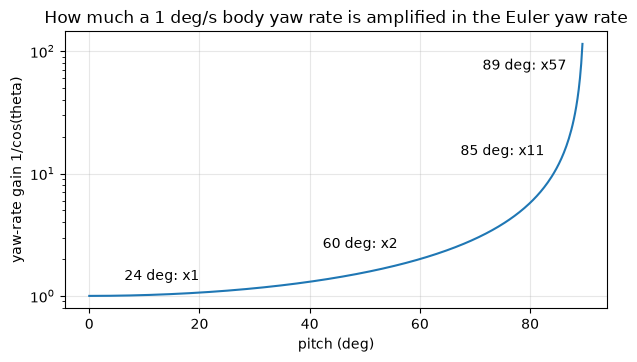

In [8]:
th = np.linspace(0, 89.5, 400)
plt.plot(th, 1 / np.cos(np.radians(th)))
for t in (24, 60, 85, 89):
    plt.annotate(f"{t} deg: x{1 / math.cos(math.radians(t)):.0f}", (t, 1 / math.cos(math.radians(t))),
                 textcoords="offset points", xytext=(-70, 8))
plt.yscale("log"); plt.xlabel("pitch (deg)"); plt.ylabel("yaw-rate gain 1/cos(theta)")
plt.title("How much a 1 deg/s body yaw rate is amplified in the Euler yaw rate"); plt.show()

In [9]:
# Climb the nose through 90 deg while yawing slowly: Euler-angle integration vs the quaternion
def euler_rates(phi, theta, p, q, r):
    return (p + (q * math.sin(phi) + r * math.cos(phi)) * math.tan(theta),
            q * math.cos(phi) - r * math.sin(phi),
            (q * math.sin(phi) + r * math.cos(phi)) / math.cos(theta))

dt = 1e-3; rates = (0.0, math.radians(30), math.radians(5))        # pitch up at 30 deg/s, small yaw, for 4 s
phi = theta = psi = 0.0; qq = np.array([1.0, 0, 0, 0]); peak = 0.0
for k in range(int(4.0 / dt)):
    dphi, dth, dpsi = euler_rates(phi, theta, *rates)
    peak = max(peak, abs(dphi), abs(dpsi))
    phi, theta, psi = phi + dphi * dt, theta + dth * dt, psi + dpsi * dt
    qq = q_normalize(qq + q_deriv(qq, np.array(rates)) * dt)
nose_euler = q_to_rotmat(q_from_euler(phi, theta, psi)) @ [1, 0, 0]
nose_quat = q_to_rotmat(qq) @ [1, 0, 0]
err = math.degrees(math.acos(max(-1.0, min(1.0, float(nose_euler @ nose_quat)))))
print(f"largest Euler-angle rate needed: {math.degrees(peak):.0f} deg/s for body rates of 30 and 5 deg/s")
print("nose after 4 s, Euler integration:", np.round(nose_euler, 3))
print("nose after 4 s, quaternion       :", np.round(nose_quat, 3), f"  -> Euler path is off by {err:.1f} deg")

largest Euler-angle rate needed: 186 deg/s for body rates of 30 and 5 deg/s
nose after 4 s, Euler integration: [-0.525  0.139 -0.84 ]
nose after 4 s, quaternion       : [-0.525  0.14  -0.84 ]   -> Euler path is off by 0.0 deg


## 5. Hover-frame angles from the quaternion

**Theory.** PX4's attitude is the structural attitude followed by the fixed hover rotation: $R^N_{\text{PX4}} = R(\mathbf q)\,R_h^{\mathsf T}$. In a perfect hover this is the identity, so PX4 reads roll = pitch = 0. The simulator's `RigidBody.hover_frame_euler` does this conversion for the tuning metrics.

In [10]:
q_hover = q_from_euler(0, math.radians(af.hover_pitch_deg), 0)
R_px4 = q_to_rotmat(q_hover) @ af.hover_rotation().T
print("R(q) R_h^T in a perfect hover =\n", np.round(R_px4, 6))

R(q) R_h^T in a perfect hover =
 [[ 1.  0.  0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]
